In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
#cargar Data:
customers_aditionals = pd.read_csv("Datos_Limpios.csv", parse_dates=["date"])

### comenzamos a analizar los datos iniciales y sus distribuciones

In [25]:
print(plt.style.available)

plt.style.use('seaborn-v0_8')

['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'petroff6', 'petroff8', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [26]:
# Convertimos 'y' a variable binaria (1 = contrató, 0 = no contrató).
# np.where es más eficiente que un apply fila por fila.
customers_aditionals["y_bin"] = np.where(customers_aditionals["y"] == "yes", 1, 0)

# Extraemos componentes temporales que usaremos en varios gráficos:
customers_aditionals["anio"] = customers_aditionals["date"].dt.year
customers_aditionals["mes"] = customers_aditionals["date"].dt.to_period("M")          # año-mes (para series mensuales)
customers_aditionals["dia_semana"] = customers_aditionals["date"].dt.day_name()        # nombre del día (Monday, Tuesday, ...)
customers_aditionals["dia_semana_num"] = customers_aditionals["date"].dt.dayofweek     # 0 = lunes ... 6 = domingo

# Orden lógico de días de la semana para que los gráficos no queden desordenados
orden_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

print("Rango de fechas:", customers_aditionals["date"].min().date(), "->", customers_aditionals["date"].max().date())
print("Total registros:", len(customers_aditionals))
print("Tasa global de contratación:", round(customers_aditionals["y_bin"].mean() * 100, 2), "%")

Rango de fechas: 2015-01-01 -> 2019-12-31
Total registros: 42285
Tasa global de contratación: 11.25 %


<Axes: title={'center': 'Reparticion de Usuarios por Edades'}, xlabel='Edad', ylabel='Recuento de Usuarios'>

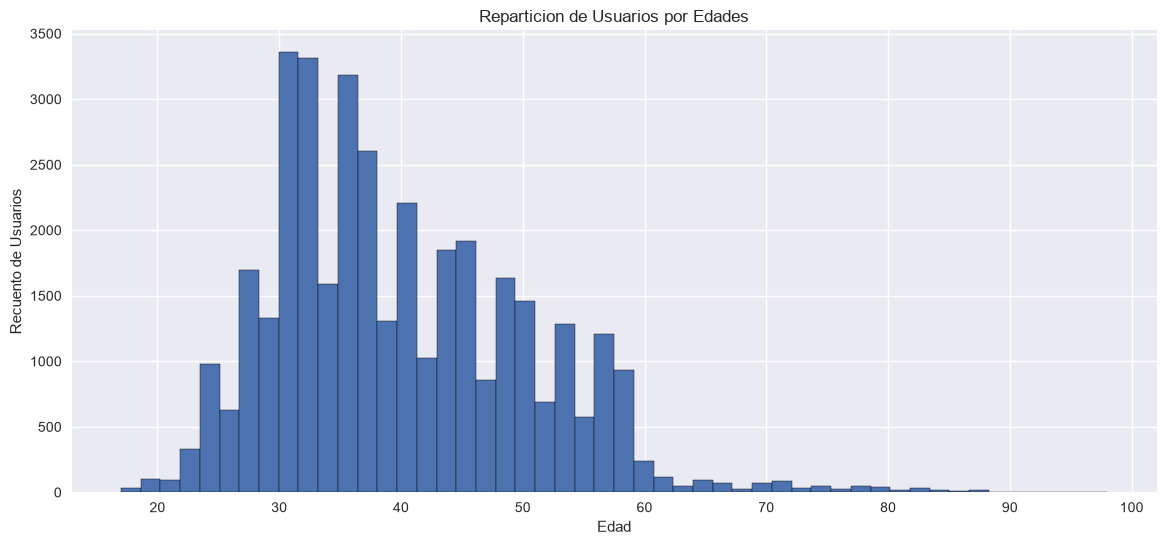

In [27]:
customers_aditionals['age'].plot(kind='hist', bins=50 ,figsize=(14,6),title="Reparticion de Usuarios por Edades",ylabel="Recuento de Usuarios",xlabel="Edad",color='#4C72B0',
edgecolor='black')

<Axes: title={'center': 'Reparticion de Usuarios por Edades'}, xlabel='Edad', ylabel='Recuento de Usuarios'>

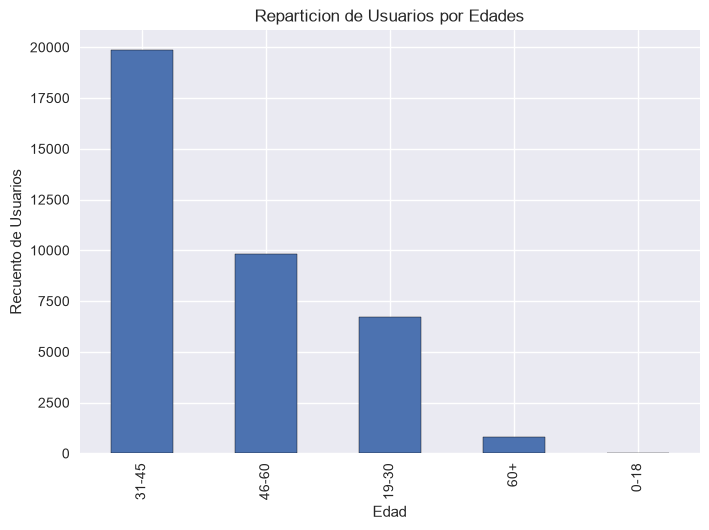

In [28]:
customers_aditionals['grupo_edad'].value_counts().plot(kind="bar",title="Reparticion de Usuarios por Edades",ylabel="Recuento de Usuarios",xlabel="Edad",color='#4C72B0',
edgecolor='black')


### 1. Variable objetivo `y` (¿contrató el depósito?)

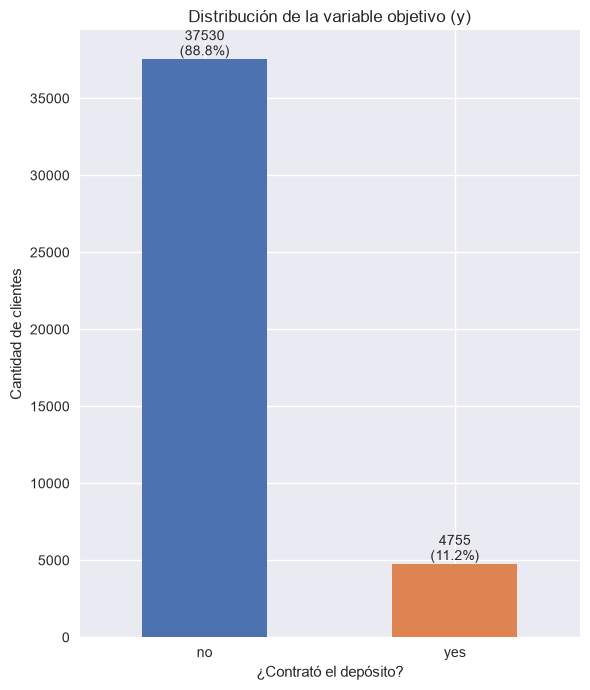

In [29]:
fig, ax = plt.subplots(figsize=(6, 7))
conteo_y = customers_aditionals['y'].value_counts()
conteo_y.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])

for i, v in enumerate(conteo_y):
    ax.text(i, v, f'{v}\n({v/conteo_y.sum():.1%})', ha='center', va='bottom')

ax.set_title('Distribución de la variable objetivo (y)')
ax.set_xlabel('¿Contrató el depósito?')
ax.set_ylabel('Cantidad de clientes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 2. Distribución de variables numéricas clave

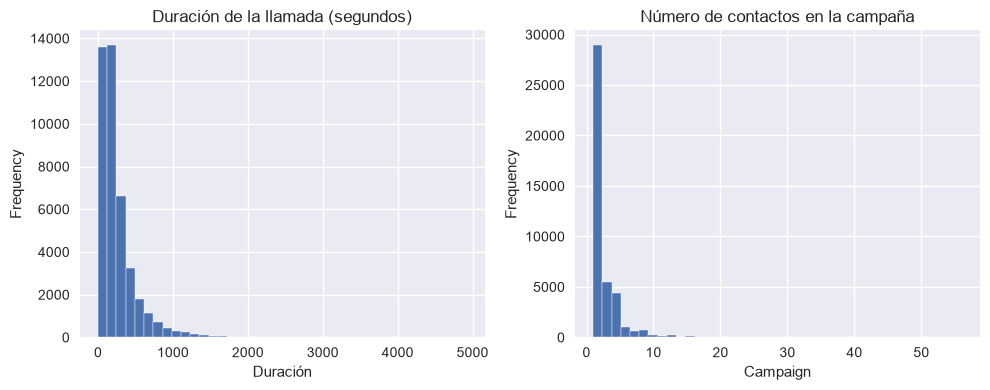

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

customers_aditionals['duration'].plot(kind='hist', bins=40, ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].set_title('Duración de la llamada (segundos)')
axes[0].set_xlabel('Duración')

customers_aditionals['campaign'].plot(kind='hist', bins=40, ax=axes[1], color='#4C72B0', edgecolor='white')
axes[1].set_title('Número de contactos en la campaña')
axes[1].set_xlabel('Campaign')

plt.tight_layout()
plt.show()

### 3. Variables categóricas principales

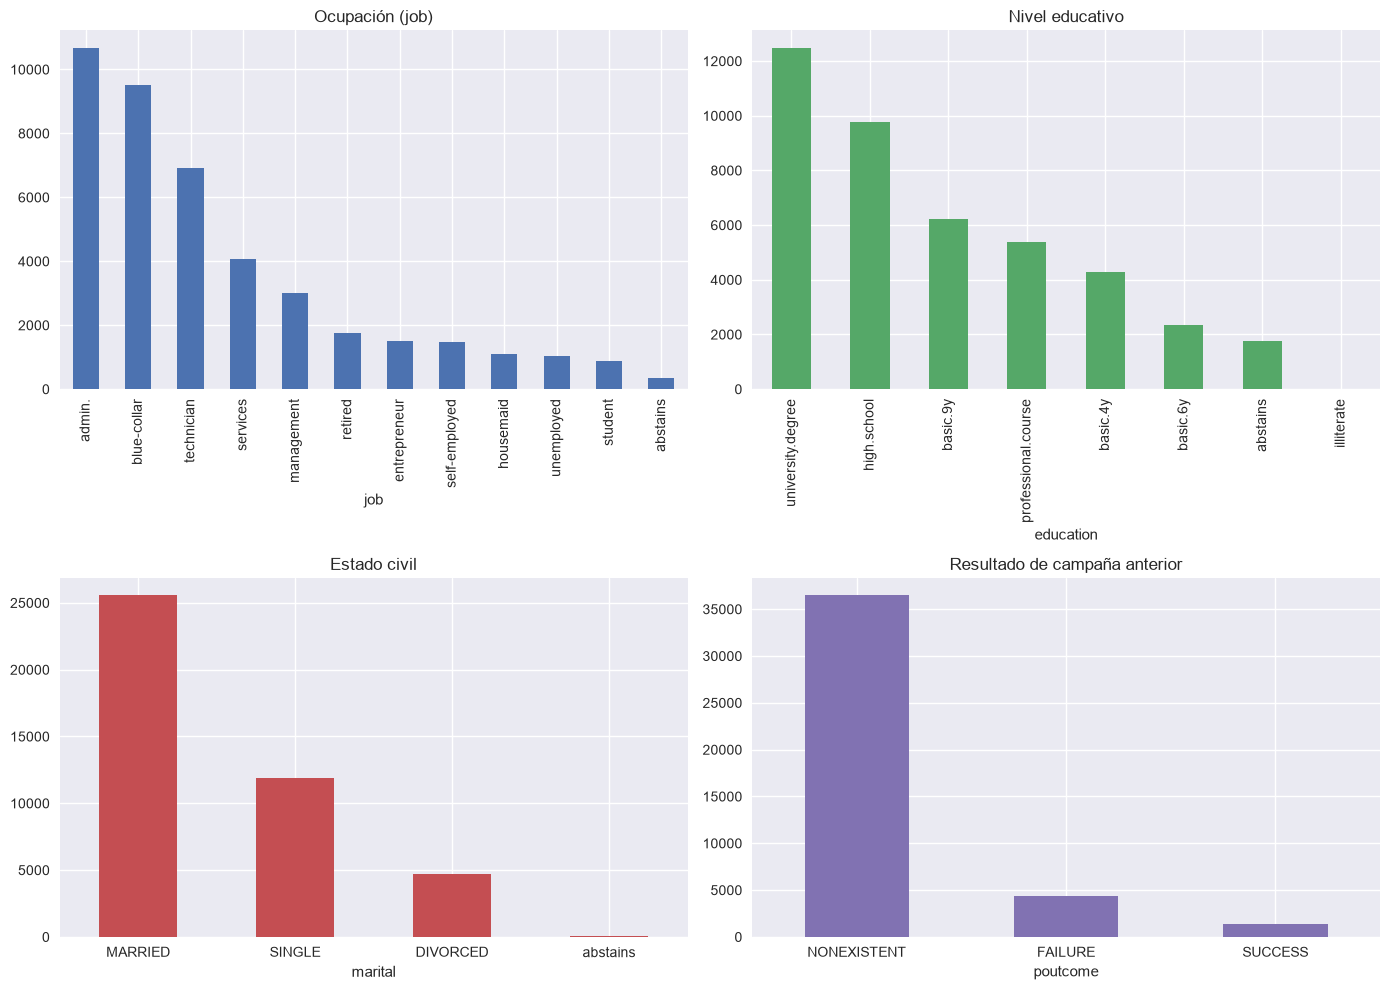

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

customers_aditionals['job'].value_counts().plot(kind='bar', ax=axes[0, 0], color='#4C72B0')
axes[0, 0].set_title('Ocupación (job)')


customers_aditionals['education'].value_counts().plot(kind='bar', ax=axes[0, 1], color='#55A868')
axes[0, 1].set_title('Nivel educativo')


customers_aditionals['marital'].value_counts().plot(kind='bar', ax=axes[1, 0], color='#C44E52')
axes[1, 0].set_title('Estado civil')
axes[1, 0].tick_params(axis='x', rotation=0)

customers_aditionals['poutcome'].value_counts().plot(kind='bar', ax=axes[1, 1], color='#8172B2')
axes[1, 1].set_title('Resultado de campaña anterior')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 4. Grupo de edad vs variable objetivo

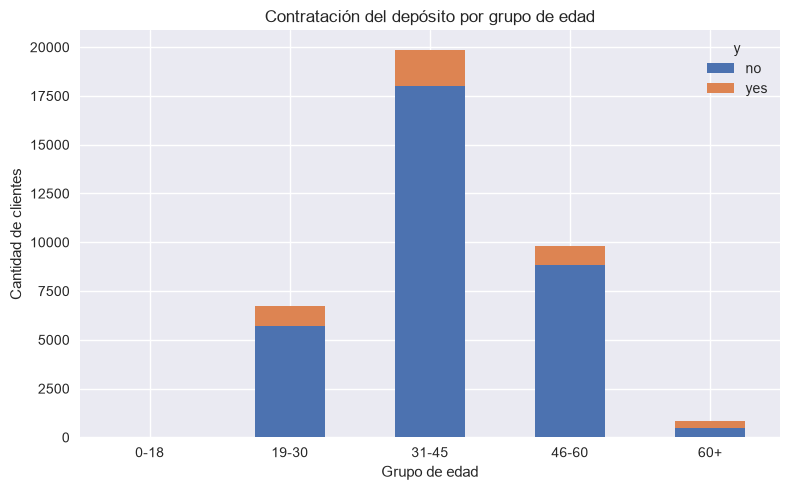

In [32]:
tabla_edad_y = pd.crosstab(customers_aditionals['grupo_edad'], customers_aditionals['y'])

fig, ax = plt.subplots(figsize=(8, 5))
tabla_edad_y.plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('Contratación del depósito por grupo de edad')
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('Cantidad de clientes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5. Duración y número de contactos según el resultado

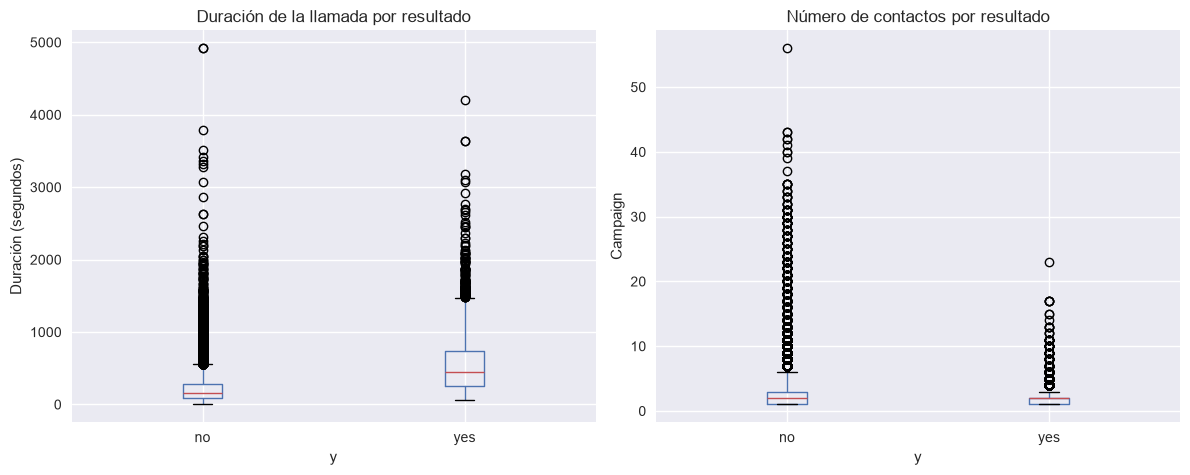

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

customers_aditionals.boxplot(column='duration', by='y', ax=axes[0])
axes[0].set_title('Duración de la llamada por resultado')
axes[0].set_xlabel('y')
axes[0].set_ylabel('Duración (segundos)')

customers_aditionals.boxplot(column='campaign', by='y', ax=axes[1])
axes[1].set_title('Número de contactos por resultado')
axes[1].set_xlabel('y')
axes[1].set_ylabel('Campaign')

plt.suptitle('')
plt.tight_layout()
plt.show()

### 6. Contactos a lo largo del tiempo

In [34]:
pd.options.display.max_columns=30
customers_aditionals.head(2)

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_,grupo_edad,y_bin,anio,mes,dia_semana,dia_semana_num
0,0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,no,2019-08-02,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,NaN,0,2019,2019-08,Friday,4
1,1,57.0,services,MARRIED,high.school,0.0,0.0,0.0,telephone,149,1,999,0,NONEXISTENT,1.1,93.994,-36.4,0.000,5191.0,no,2016-09-14,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,46-60,0,2016,2016-09,Wednesday,2


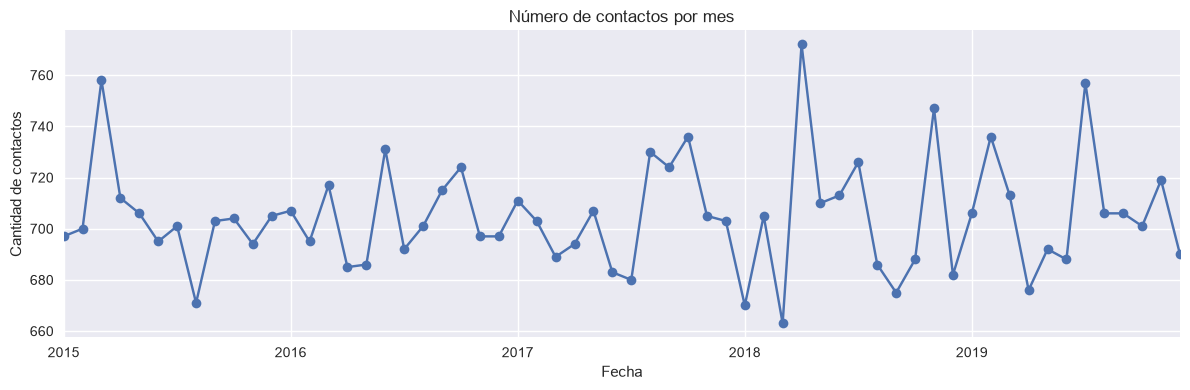

In [35]:
customers_aditionals['date'] = pd.to_datetime(customers_aditionals['date'])

contactos_por_mes = customers_aditionals.set_index('date').resample('ME').size()

fig, ax = plt.subplots(figsize=(12, 4))
contactos_por_mes.plot(kind='line', marker='o', ax=ax, color='#4C72B0')
ax.set_title('Número de contactos por mes')
ax.set_xlabel('Fecha')
ax.set_ylabel('Cantidad de contactos')
plt.tight_layout()
plt.show()

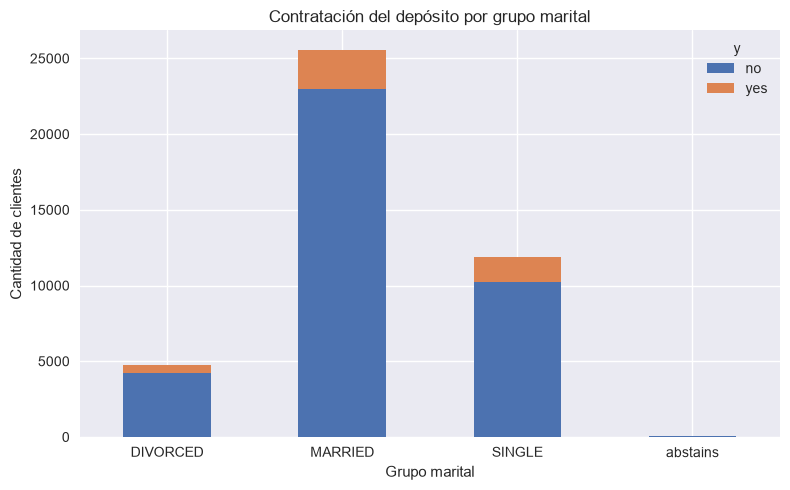

In [36]:
tabla_marital_y = pd.crosstab(customers_aditionals['marital'], customers_aditionals['y'])

fig, ax = plt.subplots(figsize=(8, 5))
tabla_marital_y.plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('Contratación del depósito por grupo marital')
ax.set_xlabel('Grupo marital')
ax.set_ylabel('Cantidad de clientes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [37]:
clientes_con_deposito = customers_aditionals[customers_aditionals['y'] == 'yes']


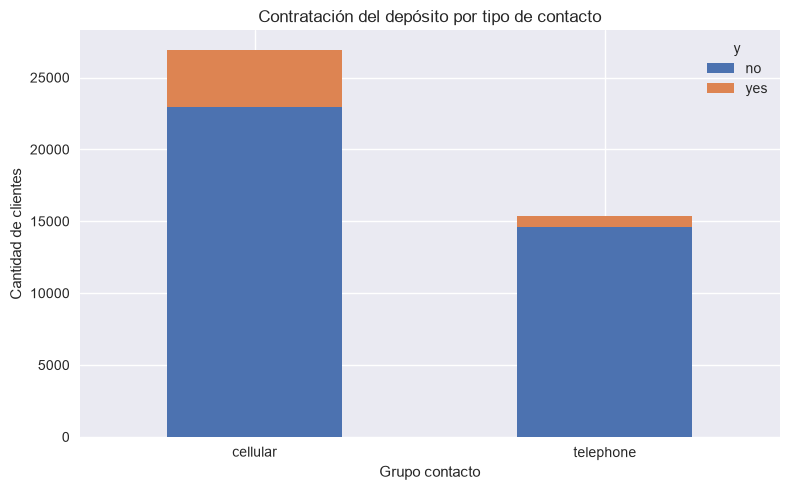

In [38]:
tabla_contact_y = pd.crosstab(customers_aditionals['contact'], customers_aditionals['y'])

fig, ax = plt.subplots(figsize=(8, 5))
tabla_contact_y.plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('Contratación del depósito por tipo de contacto')
ax.set_xlabel('Grupo contacto')
ax.set_ylabel('Cantidad de clientes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

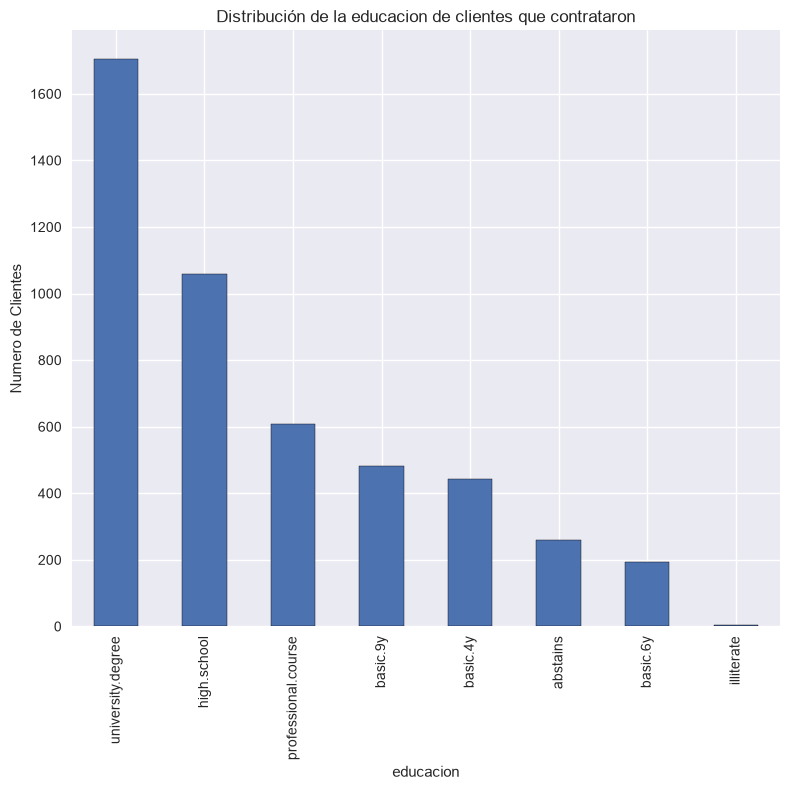

In [39]:

fig, ax = plt.subplots(figsize=(8, 8))
clientes_con_deposito['education'].value_counts().plot(kind='bar', color='#4C72B0', edgecolor='black', ax=ax)
ax.set_title('Distribución de la educacion de clientes que contrataron')
ax.set_xlabel('educacion')
ax.set_ylabel('Numero de Clientes')
plt.tight_layout()
plt.show()

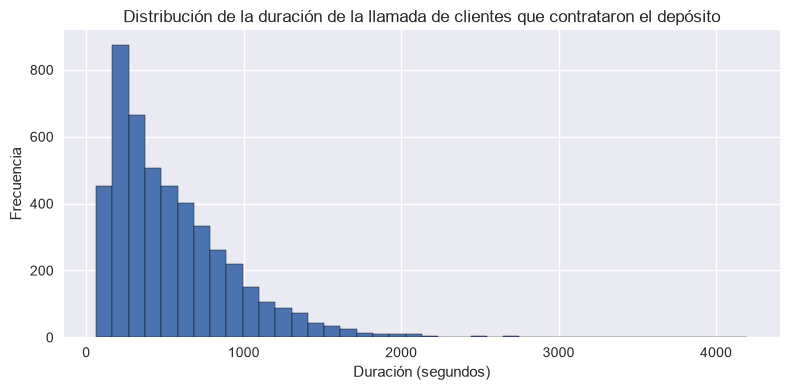

In [40]:
fig, ax = plt.subplots(figsize=(8, 4))
clientes_con_deposito['duration'].plot(kind='hist', bins=40, color='#4C72B0', edgecolor='black', ax=ax)
ax.set_title('Distribución de la duración de la llamada de clientes que contrataron el depósito')
ax.set_xlabel('Duración (segundos)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

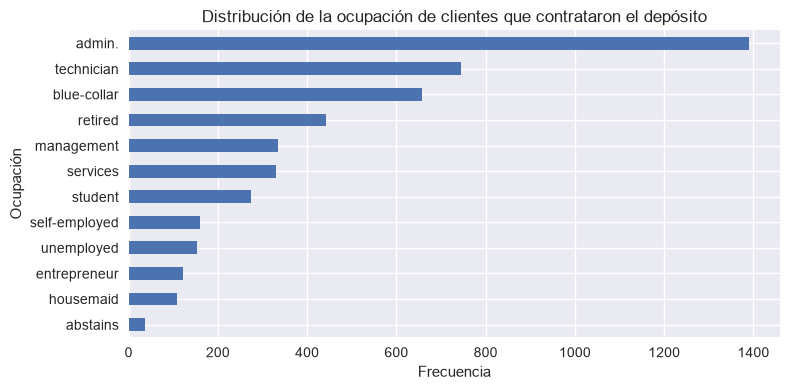

In [41]:
fig, ax = plt.subplots(figsize=(8, 4))
clientes_con_deposito['job'].value_counts().plot(kind='barh', color=['#4C72B0'], ax=ax)
ax.set_title('Distribución de la ocupación de clientes que contrataron el depósito')
ax.set_xlabel('Frecuencia')
ax.set_ylabel('Ocupación')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

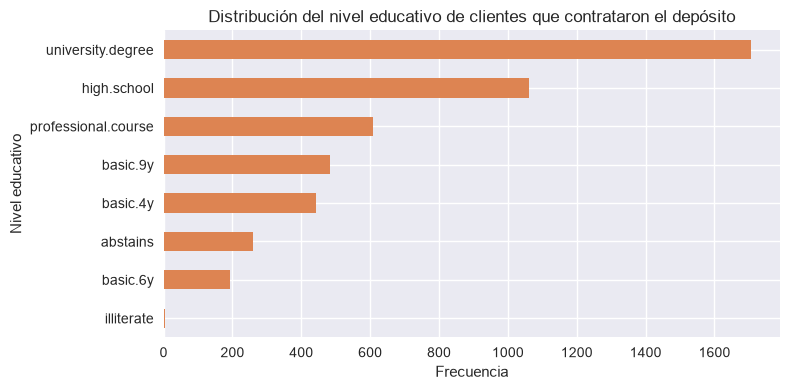

In [42]:
fig, ax = plt.subplots(figsize=(8, 4))
clientes_con_deposito['education'].value_counts().plot(kind='barh', color=['#DD8452'], ax=ax)
ax.set_title('Distribución del nivel educativo de clientes que contrataron el depósito')
ax.set_xlabel('Frecuencia')
ax.set_ylabel('Nivel educativo')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## número de contrataciones (`y` = yes) por mes

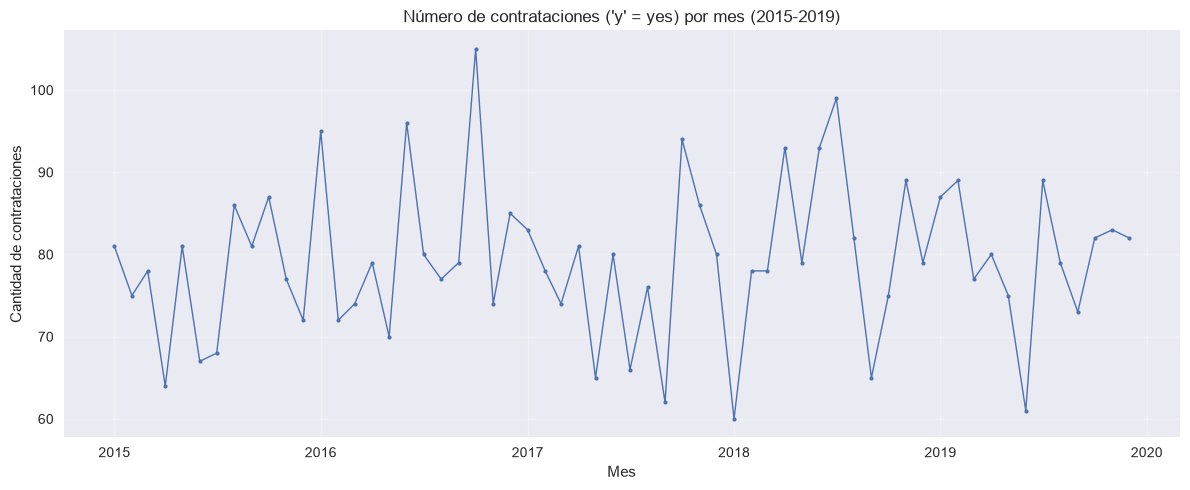

In [43]:
# Agrupamos por mes y sumamos y_bin -> total de "yes" en cada mes.
contrataciones_mensuales = customers_aditionals.groupby("mes")["y_bin"].sum()

fig, ax = plt.subplots(figsize=(12, 5))
contrataciones_mensuales.index = contrataciones_mensuales.index.to_timestamp()  # PeriodIndex -> fechas
ax.plot(contrataciones_mensuales.index, contrataciones_mensuales.values,
        marker="o", markersize=3, linewidth=1, color="#4C72B0")
ax.set_title("Número de contrataciones ('y' = yes) por mes (2015-2019)")
ax.set_xlabel("Mes")
ax.set_ylabel("Cantidad de contrataciones")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("01_contrataciones_por_mes.png", dpi=150)
plt.show()

## Tasa de contratación mensual (yes / total contactos ese mes)

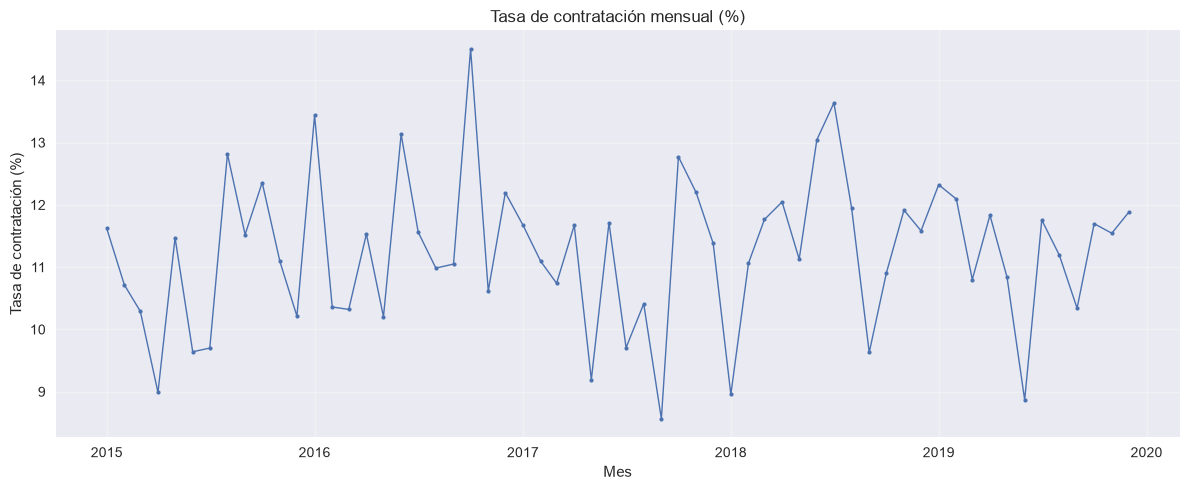

In [44]:
# A diferencia del gráfico anterior (conteo absoluto), aquí vemos la
# PROPORCIÓN de clientes que dijeron "yes" respecto al total de contactos
# de cada mes. Esto evita que meses con más volumen "dominen" el gráfico.
tasa_mensual = customers_aditionals.groupby("mes")["y_bin"].mean() * 100
tasa_mensual.index = tasa_mensual.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(tasa_mensual.index, tasa_mensual.values,
        marker="o", markersize=3, linewidth=1, color="#4C72B0")
ax.set_title("Tasa de contratación mensual (%)")
ax.set_xlabel("Mes")
ax.set_ylabel("Tasa de contratación (%)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("02_tasa_contratacion_mensual.png", dpi=150)
plt.show()

## Volumen de contactos totales por mes (contexto para las tasas)

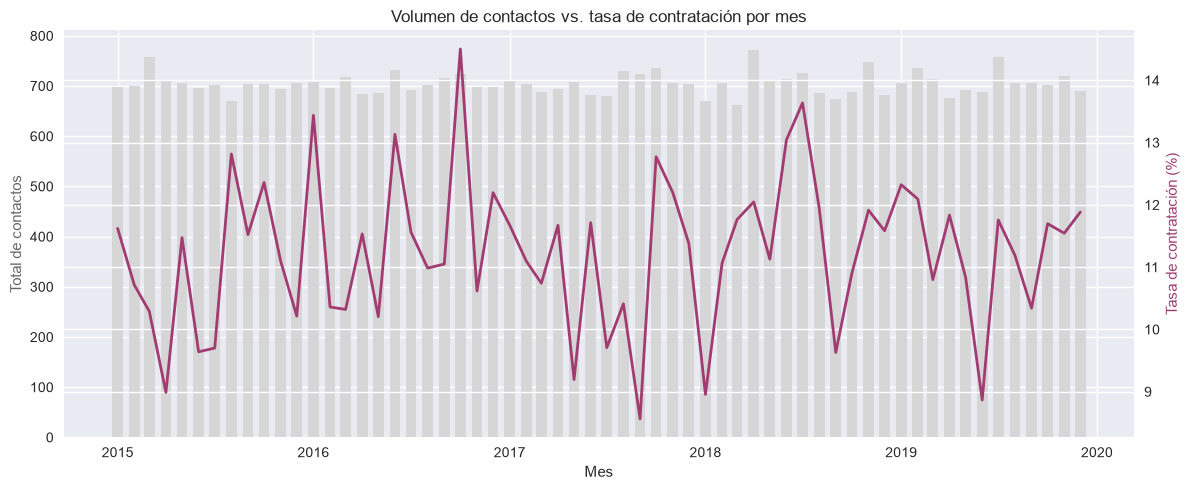

In [45]:
# Es útil mostrar el volumen total (yes + no) junto a las tasas, porque una
# tasa alta con muy pocos contactos puede ser poco representativa.
volumen_mensual = customers_aditionals.groupby("mes").size()
volumen_mensual.index = volumen_mensual.index.to_timestamp()

fig, ax1 = plt.subplots(figsize=(12, 5))

# Barras: volumen total de contactos por mes (eje izquierdo)
ax1.bar(volumen_mensual.index, volumen_mensual.values, width=20,
        color="#D6D6D6", label="Total de contactos")
ax1.set_xlabel("Mes")
ax1.set_ylabel("Total de contactos", color="#666666")
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Línea: tasa de contratación (eje derecho), comparte el mismo eje X
ax2 = ax1.twinx()
ax2.plot(tasa_mensual.index, tasa_mensual.values,
         color="#A23B72", linewidth=2, label="Tasa de contratación (%)")
ax2.set_ylabel("Tasa de contratación (%)", color="#A23B72")

ax1.set_title("Volumen de contactos vs. tasa de contratación por mes")
fig.tight_layout()
fig.savefig("06_volumen_vs_tasa.png", dpi=150)
plt.show()

## Comparativa anual: contrataciones "yes" vs "no" por año

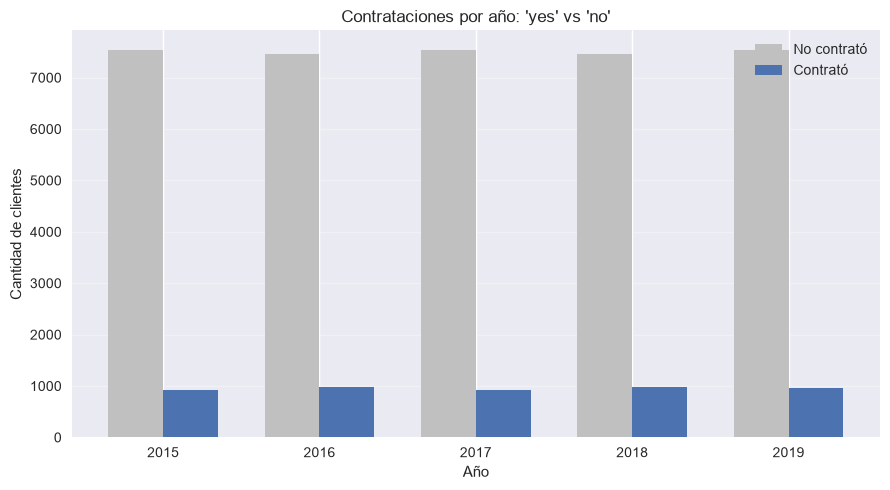

In [46]:
# crosstab arma una tabla anio x y con el conteo de cada combinación.
tabla_anual = pd.crosstab(customers_aditionals["anio"], customers_aditionals["y"])

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(tabla_anual.index))  # posiciones base en el eje X
ancho = 0.35                            # ancho de cada barra

ax.bar(x - ancho/2, tabla_anual["no"], width=ancho, label="No contrató", color="#C0C0C0")
ax.bar(x + ancho/2, tabla_anual["yes"], width=ancho, label="Contrató", color="#4C72B0")

ax.set_title("Contrataciones por año: 'yes' vs 'no'")
ax.set_xlabel("Año")
ax.set_ylabel("Cantidad de clientes")
ax.set_xticks(x)
ax.set_xticklabels(tabla_anual.index)
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig("03_comparativa_anual_yes_no.png", dpi=150)
plt.show()

## mapa de calor de correlaciones

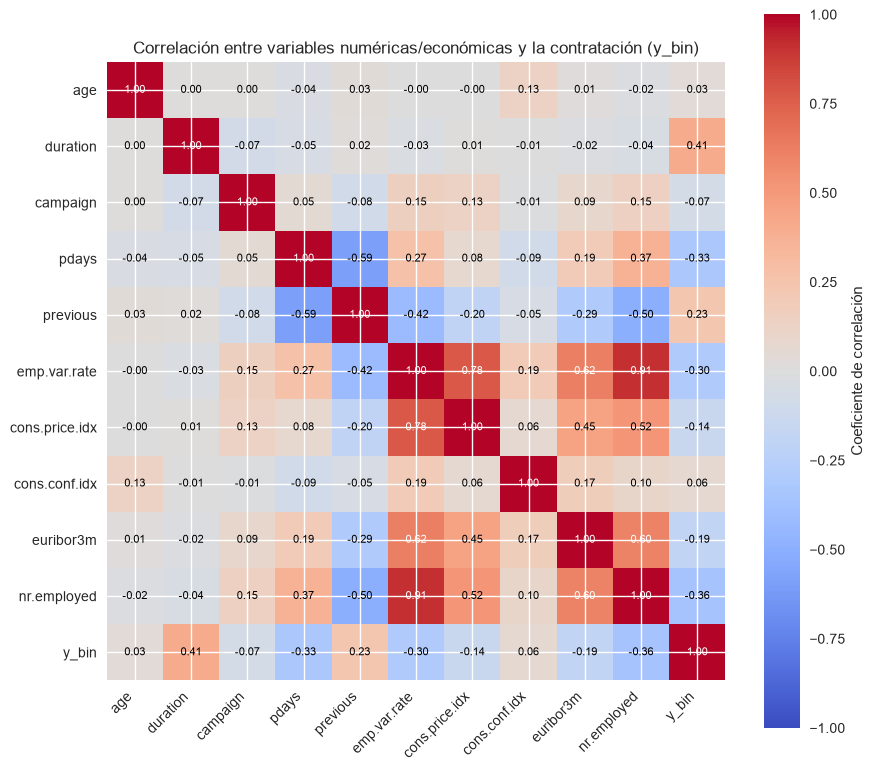

In [47]:
# Reunimos las variables numéricas y económicas más relevantes junto con
# y_bin (1 = contrató, 0 = no contrató) para ver de un vistazo qué
# variables se relacionan más con la contratación del depósito.
columnas_correlacion = [
    'age', 'duration', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed', 'y_bin'
]

matriz_corr = customers_aditionals[columnas_correlacion].corr()

fig, ax = plt.subplots(figsize=(9, 8))

# imshow dibuja la matriz como una grilla de colores (heatmap)
im = ax.imshow(matriz_corr, cmap='coolwarm', vmin=-1, vmax=1)

# Ejes con los nombres de las variables
ax.set_xticks(np.arange(len(columnas_correlacion)))
ax.set_yticks(np.arange(len(columnas_correlacion)))
ax.set_xticklabels(columnas_correlacion, rotation=45, ha='right')
ax.set_yticklabels(columnas_correlacion)

# Anotamos cada celda con su valor de correlación para lectura rápida
for i in range(len(columnas_correlacion)):
    for j in range(len(columnas_correlacion)):
        valor = matriz_corr.iloc[i, j]
        color_texto = 'white' if abs(valor) > 0.6 else 'black'
        ax.text(j, i, f'{valor:.2f}', ha='center', va='center',
                color=color_texto, fontsize=8)

ax.set_title('Correlación entre variables numéricas/económicas y la contratación (y_bin)')
fig.colorbar(im, ax=ax, label='Coeficiente de correlación')
plt.tight_layout()
plt.show()